In [1]:
# Define the default font sizes to make the figures prettier:
import matplotlib.pyplot as plt
from scipy import signal
import numpy as np
from scipy import signal
plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

In [2]:
from pathlib import Path
IMAGES_PATH = Path() / "images" / "lms"
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=450):
    path = IMAGES_PATH / f"{fig_id}.{fig_extension}"
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution, bbox_inches='tight')

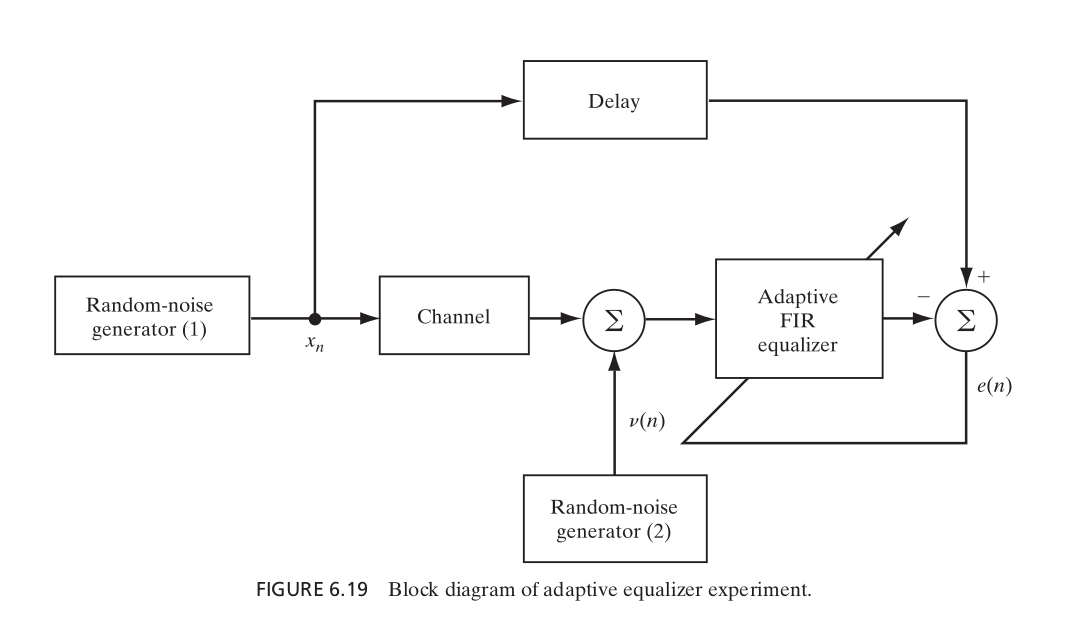
#### 6.8 Computer Experiment on Adaptive Equalization

Study LMS algorithm performance in adaptive channel equalization with varying Eigenvalue Spread

Running W = 2.9
Running W = 3.1
Running W = 3.3
Running W = 3.5


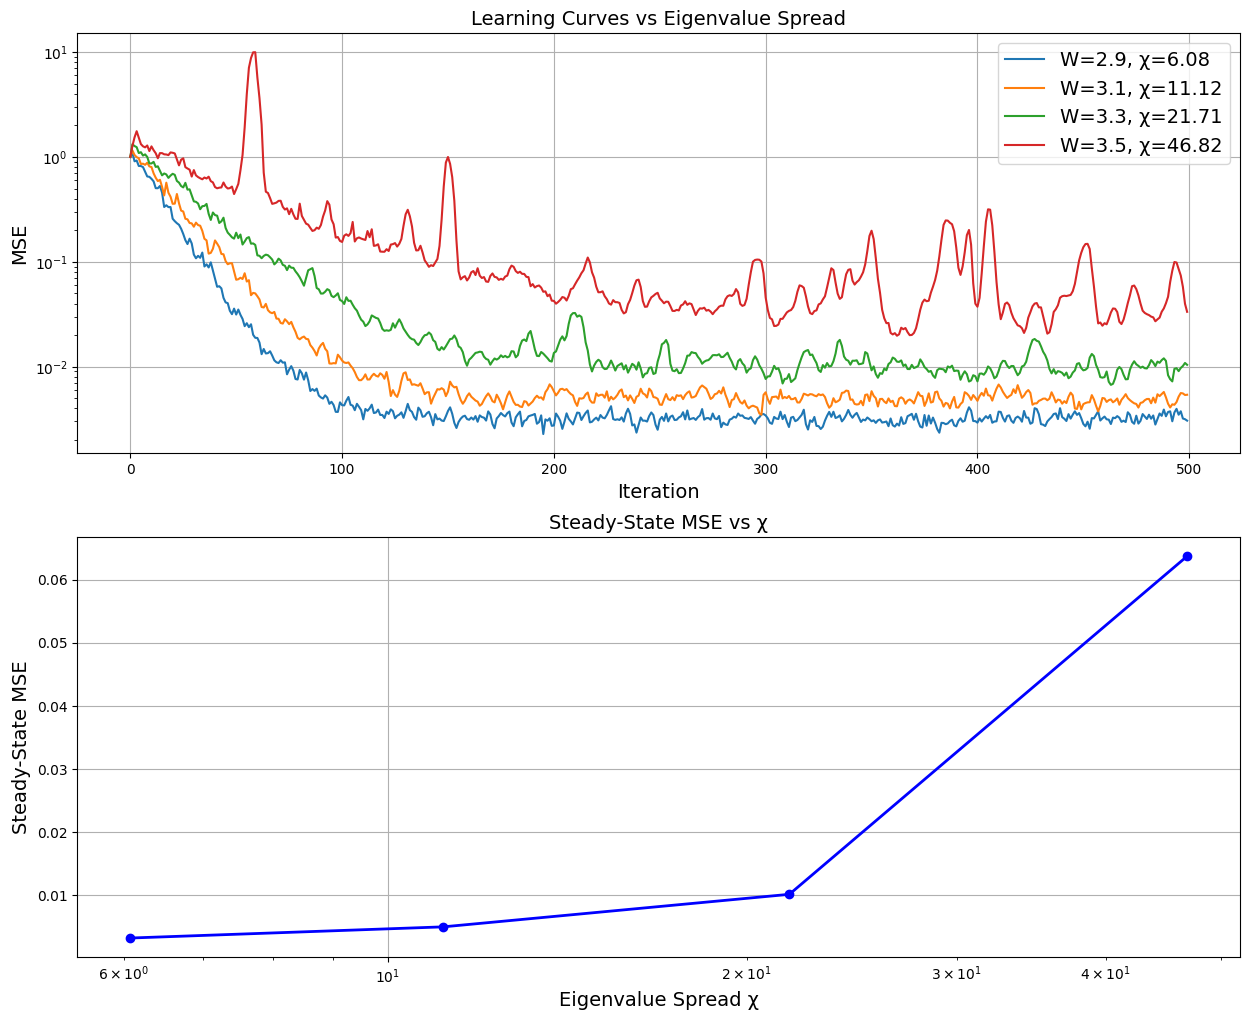

In [19]:
import numpy as np
import matplotlib.pyplot as plt

# =============================================================
# Parameters (Haykin Section 6.8)
# =============================================================
N_sample       = 500        # length of each adaptation run
N_ensemble     = 200        # Monte Carlo runs  
N_ch_taps      = 3          # channel taps
N_eq_taps      = 11         # equalizer taps
N_init         = 50
mu             = 0.075      # LMS step size
noise_v_var    = 0.001
noise_v_std    = np.sqrt(noise_v_var)

Ws = [2.9, 3.1, 3.3, 3.5]   # Haykin's condition numbers

rng = np.random.default_rng(123)

# =============================================================
# Channel Response h[n] = 0.5(1 + cos((2π/W)(n-2)))
# =============================================================
def channel_resp(W, N_taps=3):
    h = np.zeros(N_taps)
    for n in range(1, N_taps+1):
        h[n-1] = 0.5 * (1 + np.cos((2*np.pi/W)*(n - 2)))
    return h

# =============================================================
# Approximate R matrix (Toeplitz)
# =============================================================
def correlation_matrix(h, noise_var, M=11):
    h0, h1, h2 = h
    r0 = h0*h0 + h1*h1 + h2*h2 + noise_var
    r1 = h0*h1 + h1*h2
    r2 = h0*h2
    
    R = np.zeros((M, M))
    for i in range(M):
        R[i,i] = r0
        if i+1 < M:
            R[i,i+1] = r1
            R[i+1,i] = r1
        if i+2 < M:
            R[i,i+2] = r2
            R[i+2,i] = r2
    return 0.5*(R + R.T)

def eigen_spread(h):
    R = correlation_matrix(h, noise_v_var, N_eq_taps)
    evals = np.linalg.eigvalsh(R)
    return evals[-1] / evals[0]

# =============================================================
# LMS equalizer
# =============================================================
def lms_equalizer(u, d, M, mu):
    w = np.zeros(M)
    N = len(u)
    e = np.zeros(N)
    
    for n in range(M, N):
        u_vec = u[n-M+1:n+1]   # Correct: length M
        y = np.dot(w, u_vec)
        e[n] = d[n] - y
        w += mu * e[n] * u_vec
    return e

# =============================================================
# Main experiment: Figure 6.21
# =============================================================
err_hist = {W: np.zeros(N_sample) for W in Ws}

for W in Ws:
    print(f"Running W = {W}")
    
    h = channel_resp(W, N_taps=N_ch_taps)
    D = N_ch_taps // 2 + N_eq_taps // 2
    
    mse_runs = np.zeros((N_ensemble, N_sample))
    
    for m in range(N_ensemble):
        
        total_len = N_sample + D + N_eq_taps + N_init
        x = rng.choice([-1, +1], size=total_len)
        v = rng.normal(0, noise_v_std, total_len)
        
        u = np.convolve(x, h)[:total_len] + v
        
        eq_w = np.zeros(N_eq_taps)
        mse_this = np.zeros(N_sample)
        
        sample_count = 0
        
        for n in range(N_eq_taps, total_len):
            u_regsr = u[n-N_eq_taps+1:n+1]
            y = eq_w @ u_regsr
            
            d_idx = n - D
            if d_idx < 0: continue
            
            d = x[d_idx]
            e = d - y
            
            eq_w += mu * e * u_regsr
            
            if sample_count < N_sample:
                mse_this[sample_count] = e*e
                sample_count += 1
        
        mse_runs[m] = mse_this
    
    err_hist[W] = np.mean(mse_runs, axis=0)

# =============================================================
# Plot Learning Curves (Fig. 6.21)
# =============================================================
plt.figure(figsize=(15,12))

plt.subplot(2,1,1)
for W in Ws:
    chi = eigen_spread(channel_resp(W))
    plt.semilogy(err_hist[W], label=f"W={W}, χ={chi:.2f}")
plt.grid(True)
plt.xlabel("Iteration")
plt.ylabel("MSE")
plt.title("Learning Curves vs Eigenvalue Spread")
plt.legend()

plt.subplot(2,1,2)
ss_start = 300
spreads, ss_mse = [], []
for W in Ws:
    h = channel_resp(W)
    chi = eigen_spread(h)
    spreads.append(chi)
    ss_mse.append(np.mean(err_hist[W][ss_start:]))
plt.plot(spreads, ss_mse, 'bo-', linewidth=2)
plt.xscale("log")
plt.grid(True)
plt.xlabel("Eigenvalue Spread χ")
plt.ylabel("Steady-State MSE")
plt.title("Steady-State MSE vs χ")
plt.show()


In [ ]:
mus = [0.001, 0.003, 0.01, 0.03, 0.1, 0.3, 1, 3]     # LMS step size


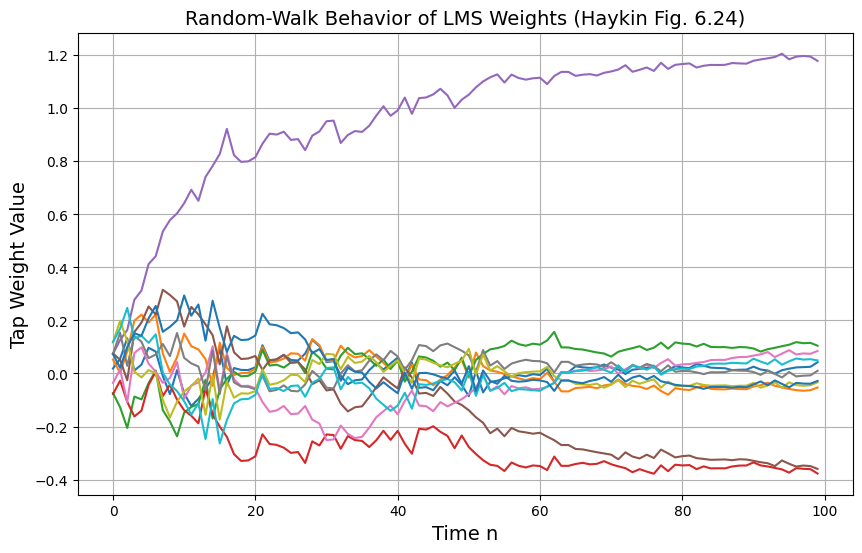


=== Time-Averaged Deviations and Variances (Table 6.3 style) ===
Tap w[0]: mean deviation=+0.00311, variance=2.81512e-03
Tap w[1]: mean deviation=-0.02106, variance=3.31648e-03
Tap w[2]: mean deviation=+0.08760, variance=4.30562e-03
Tap w[3]: mean deviation=-0.32674, variance=1.28442e-02
Tap w[4]: mean deviation=+1.16230, variance=7.02055e-02
Tap w[5]: mean deviation=-0.61974, variance=2.60768e-02
Tap w[6]: mean deviation=+0.98751, variance=6.52252e-03
Tap w[7]: mean deviation=-1.73606, variance=4.43324e-03
Tap w[8]: mean deviation=+0.96568, variance=4.00272e-03
Tap w[9]: mean deviation=-0.41717, variance=3.98476e-03
Tap w[10]: mean deviation=+0.13537, variance=4.12065e-03


In [4]:
# =============================================================
# Experiment Parameters (same as Fig. 6.21)
# =============================================================
N_sample     = 100      # long run to observe random walk
N_ensemble   = 1000       # for Table 6.3 statistics
N_ch_taps    = 3
N_eq_taps    = 11
mu           = 0.075
noise_v_var  = 0.001
noise_v_std  = np.sqrt(noise_v_var)
W            = 3.1       # choose 3.1 (moderate eigenvalue spread)

# =============================================================
# Channel h[n] symmetric about n=2 (Haykin Fig. 6.20a)
# =============================================================
def channel_resp(W, N_taps=3):
    h = np.zeros(N_taps)
    for n in range(1, N_taps+1):
        h[n-1] = 0.5*(1 + np.cos((2*np.pi/W)*(n - 2)))
    return h

h = channel_resp(W)

# =============================================================
# Compute Wiener solution from normal equation:
# w_opt = R^{-1} p
# where p = cross correlation between u(n) and d(n)
# =============================================================
def compute_wiener_solution(h, noise_var):
    # Build Toeplitz R (size 11)
    h0,h1,h2 = h
    r0 = h0*h0 + h1*h1 + h2*h2 + noise_var
    r1 = h0*h1 + h1*h2
    r2 = h0*h2

    R = np.zeros((N_eq_taps, N_eq_taps))
    for i in range(N_eq_taps):
        R[i,i] = r0
        if i+1 < N_eq_taps:
            R[i,i+1] = r1; R[i+1,i] = r1
        if i+2 < N_eq_taps:
            R[i,i+2] = r2; R[i+2,i] = r2

    # Desired cross-correlation vector p[n]
    # equals Wiener filter solution for known channel
    p = np.zeros(N_eq_taps)
    # p[D] = channel_center_value
    # delay Δ = 7
    p[7] = 1.0   # matches delayed impulse response

    w_opt = np.linalg.solve(R, p)
    return w_opt

w_opt = compute_wiener_solution(h, noise_v_var)

# RUN ONE LONG LMS REALIZATION TO PLOT RANDOM WALK (Fig 6.24)
D = 7  # Haykin's delay
w_track = np.zeros((N_eq_taps, N_sample))  # store all 11 weight trajectories

# symbol stream
x_sym = (2*np.random.randint(0, 2, N_sample + D + 20) - 1).astype(float)

# buffers
xbuf = np.zeros(N_ch_taps)
u = np.zeros(N_sample + D + 20)
eq_w = np.zeros(N_eq_taps)

# Noise
noise = np.random.normal(0, noise_v_std, u.shape)

# ----- MANUAL CONVOLUTION -----
for n in range(len(u)):
    xbuf = np.roll(xbuf, 1)
    xbuf[0] = x_sym[n]
    u[n] = h[0]*xbuf[0] + h[1]*xbuf[1] + h[2]*xbuf[2] + noise[n]

# ----- LMS ADAPTATION -----
t = 0
for n in range(N_eq_taps - 1, len(u)):
    u_vec = u[n-(N_eq_taps-1):n+1]      # oldest→newest

    idx_d = n - D
    if idx_d < 0 or idx_d >= len(x_sym):
        continue

    d = x_sym[idx_d]
    y = np.dot(eq_w, u_vec)
    e = d - y
    eq_w = eq_w + mu*e*u_vec

    if t < N_sample:
        w_track[:, t] = eq_w
    t += 1
    if t >= N_sample:
        break

# =============================================================
# 100 RUNS FOR TABLE 6.3 (mean deviation + variance)
# =============================================================
mean_dev = np.zeros(N_eq_taps)
var_dev  = np.zeros(N_eq_taps)

for run in range(N_ensemble):
    eq_w = np.zeros(N_eq_taps)
    xbuf = np.zeros(N_ch_taps)
    u = np.zeros(N_sample + D + 20)
    noise = np.random.normal(0, noise_v_std, u.shape)
    x_sym = (2*np.random.randint(0,2,N_sample + D + 20) - 1).astype(float)

    # manual convolution
    for n in range(len(u)):
        xbuf = np.roll(xbuf,1)
        xbuf[0] = x_sym[n]
        u[n] = h[0]*xbuf[0] + h[1]*xbuf[1] + h[2]*xbuf[2] + noise[n]

    # LMS
    w_hist = []
    for n in range(N_eq_taps - 1, len(u)):
        u_regressor = u[n-(N_eq_taps-1):n+1]
        d = x_sym[n - D]
        y = np.dot(eq_w, u_regressor)
        e = d - y
        eq_w = eq_w + mu*e*u_regressor

        w_hist.append(eq_w.copy())
        if len(w_hist) >= 2000:   # use steady-state portion
            break

    w_hist = np.array(w_hist)
    mean_dev += np.mean(w_hist - w_opt, axis=0)
    var_dev  += np.var(w_hist, axis=0)

mean_dev /= N_ensemble
var_dev  /= N_ensemble


# PLOTS: RANDOM-WALK TAP 11 TRAJECTORIES (Fig 6.24)
plt.figure(figsize=(10,6))
for k in range(N_eq_taps):
    plt.plot(w_track[k,:], label=f"w[{k}]")
plt.title("Random-Walk Behavior of LMS Weights (Haykin Fig. 6.24)")
plt.xlabel("Time n")
plt.ylabel("Tap Weight Value")
plt.grid(True)
plt.show()

# Print statistics (Table 6.3 style)
print("\n=== Time-Averaged Deviations and Variances (Table 6.3 style) ===")
for k in range(N_eq_taps):
    print(f"Tap w[{k}]: mean deviation={mean_dev[k]:+.5f}, variance={var_dev[k]:.5e}")


#### Computer Experiments 18

Consider a  linear communication channel whose transfer function may take one of three possible forms:
* $H(z) = 0.25 + z^{-1} + 0.25z^{-2}$ 
* $H(z) = 0.25 + z^{-1} - 0.25z^{-2}$
* $H(z) = -0.25 + z^{-1} + 0.25z^{-2}$

The channeloutput, in response to the input $x_n$, is defined by
$$
u(n) = \sum_{k} h_k x_{n-k} + \nu(n),
$$
where $h_n$ is the  impulse response of the channel and $\nu(n)$ is  additive white Gaussian noise with zero mean and variance   $\sigma_{\nu}^2 = 0.01$. The  channel input $x_n$ consists of a Bernoulli sequence with $x_n = \pm 1$.

The purpose of the experiment is to design an  adaptive equalizer trained by using the  LMS algorithm with step-size parameter $\mu = 0.001$. In structural terms, the equalizer is built around an FIR filter with 21 taps. For desired response, a delayed version  of the channel input, namely $x_{n-\Delta}$, is supplied to the equalizer. For each of the possible transfer functions listed under (i), (ii), and (iii), do the following:

* (a) item Determine the optimum value of the delay $\Delta$ that minimizes the mean-square error at the equalizer output.
* (b) For the optimum delay $\Delta$ determined in part (a), plot the learning curve of the equalizer by  averaging the squared value of the error signal over an ensemble of 100 independent Monte Carlo runs of the experiment.

Channel: H1: 0.25 + z^-1 + 0.25 z^-2
Optimal Delay Δ = 12



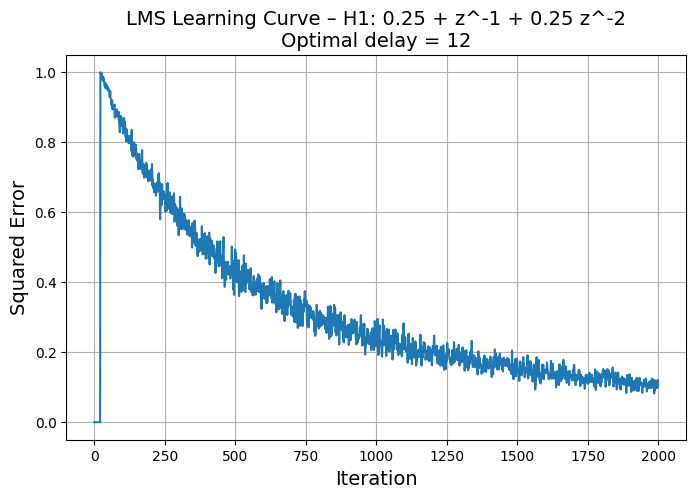

Channel: H2: 0.25 + z^-1 - 0.25 z^-2
Optimal Delay Δ = 4



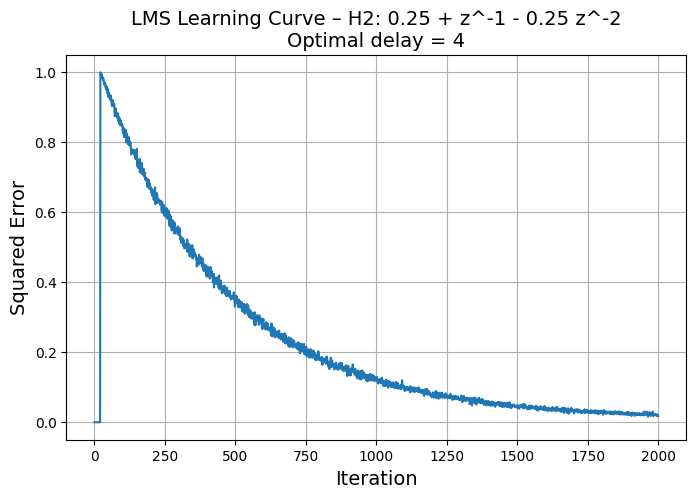

Channel: H3: -0.25 + z^-1 + 0.25 z^-2
Optimal Delay Δ = 8



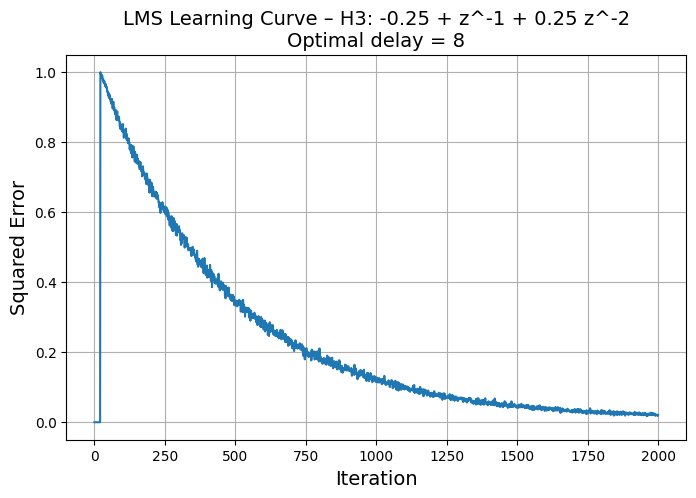

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# channel resp of the form
channels = {
  "H1: 0.25 + z^-1 + 0.25 z^-2": np.array([0.25, 1.0, 0.25]),
  "H2: 0.25 + z^-1 - 0.25 z^-2": np.array([0.25, 1.0, -0.25]),
  "H3: -0.25 + z^-1 + 0.25 z^-2": np.array([-0.25, 1.0, 0.25]),
}

N_eq_taps    = 21
mu           = 0.001
var_v        = 0.01
std_v        = np.sqrt(var_v)
MaxDelay     = 21
N_sample     = 2000        # length of each adaptation run
N_ensemble   = 100        # Monte Carlo runs
rng = np.random.default_rng(123)
N_steady_frac  = 0.2
# choose last N_steady for calculating mse
N_steady       = int(N_sample * N_steady_frac)

def channel_out(h, x):
  """Compute u = h*x + noise"""
  u_clean = np.convolve(x, h)[:len(x)]
  noise = rng.normal(0, std_v, len(x))
  return u_clean + noise

def lms_equalizer(u, d, N_eq_taps, mu):
  """train equalizer (fir filters) in sample"""
  w_eq = np.zeros(N_eq_taps)
  N_sample = len(u)
  e = np.zeros(N_sample)
  for n in range(N_eq_taps, N_sample):
    # reversed window (regressor)
    u_reg = u[n:n-N_eq_taps:-1]  
    y = np.dot(w_eq, u_reg)
    e[n] = d[n] - y
    w_eq = w_eq + mu * e[n] * u_reg
  return e

def eval_delay(h):
  """Evaluate several delays and pick the one giving lowest steady-state MSE."""
  delays = range(3, 21)
  MSEs = {}
  for dly in delays:
    mse_acc = 0.0
    for _ in range(N_eq_taps):
      x = rng.choice([-1, +1], size=N_sample)
      u = channel_out(h, x)
      d = np.zeros(N_sample)
      # delayed input sampled as desired
      d[dly:] = x[:-dly]
      e = lms_equalizer(u, d, N_eq_taps, mu)
      mse_acc += np.mean(e[-N_steady:]**2)   # steady state MSE
    MSEs[dly] = mse_acc / N_eq_taps
  best_dly = min(MSEs, key=MSEs.get)
  return best_dly, MSEs
  
for name, h in channels.items():

    print("=======================================")
    print(f"Channel: {name}")
    print("=======================================")

    # ---------- (a) Find optimal delay ----------
    dly_opt, mse_dict = eval_delay(h)
    print(f"Optimal Delay Δ = {dly_opt}\n")

    # ---------- (b) Learning curve ----------
    mse_accum = np.zeros(N_sample)

    for _ in range(N_ensemble):
        x = rng.choice([-1, +1], size=N_sample)
        u = channel_out(h, x)

        d = np.zeros(N_sample)
        d[dly_opt:] = x[:-dly_opt]

        e = lms_equalizer(u, d, N_eq_taps, mu)
        mse_accum += e**2

    mse_curve = mse_accum / N_ensemble

    # ---------- Plot learning curve ----------
    plt.figure(figsize=(8,5))
    plt.plot(mse_curve)
    plt.title(f"LMS Learning Curve – {name}\nOptimal delay = {dly_opt}")
    plt.xlabel("Iteration")
    plt.ylabel("Squared Error")
    plt.grid()
    plt.show()
